# Time Series Forecasting - Team 8

# Pre-process Dataset

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display
from google.colab import drive

# Step 1: Download (only if needed)
if not os.path.exists("train.parquet"):
    print("Downloading datasets...")
    !gdown --id 1t1WRvcf2vRKypP_gwOZzUdQNgAsYgcMR -O train.parquet
if not os.path.exists("test.parquet"):
    !gdown --id 1jGh1vmFZMu2uapqF9trm3KZ2A6_elLHx -O test.parquet

# Step 2: Load (fast - local disk)
print("Loading data...")
train_df = pl.scan_parquet("train.parquet")
test_df  = pl.scan_parquet("test.parquet")
print("Data ready. Loading lazily...")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1t1WRvcf2vRKypP_gwOZzUdQNgAsYgcMR
From (redirected): https://drive.google.com/uc?id=1t1WRvcf2vRKypP_gwOZzUdQNgAsYgcMR&confirm=t&uuid=e9e90c48-f637-4b3f-9a4c-2ceae3179738
To: /content/train.parquet
100% 776M/776M [00:11<00:00, 67.2MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1jGh1vmFZMu2uapqF9trm3KZ2A6_elLHx
From (redirected): https://drive.google.com/uc?id=1jGh1vmFZMu2uapqF9trm3KZ2A6_elLHx&confirm=t&uuid=a9c31cd8-ded5-4cc8-b4d9-bb555c2aa8b2
To: /content/test.parquet


In [8]:
# Print schema
print(test_df.schema)

# Get shape (forces minimal computation)
print("\n\nTrain shape:", train_df.select(pl.len()).collect())
print("\n\nTest shape:", test_df.select(pl.len()).collect())

# Preview data (only loads small sample)
print("\n\nTraining data preview:")
display(train_df.head(5).collect())
print("\n\nTesting data preview:")
display(test_df.head(5).collect())

Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float64, 'feature_am': Float64, 'feature_an'

/tmp/ipykernel_124887/1444013852.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(test_df.schema)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7



Testing data preview:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [13]:
train_df = (
    pl.scan_parquet("train.parquet")
    .sort(["code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

/tmp/ipykernel_124887/1691312380.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_df = train_df.collect(streaming=True)


In [14]:
num_cols = [col for col in train_df.columns if col not in ["code", "ts_index"]]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over("code")
    .alias(col)
    for col in num_cols
])

# Median imputation
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over("code"))
    .alias(col)
    for col in num_cols
])

Summary Statistics

In [11]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061604  ┆ 2.323426  ┆

Feature Distributions

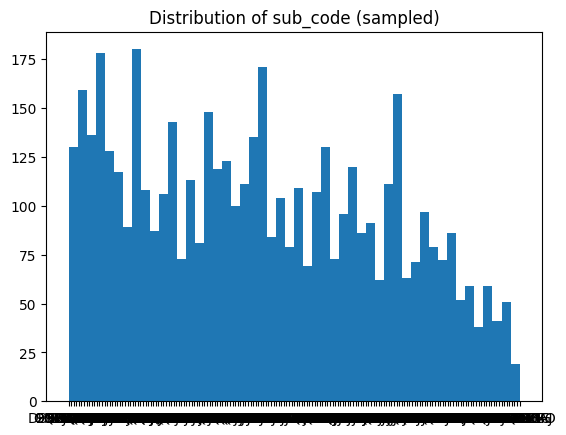

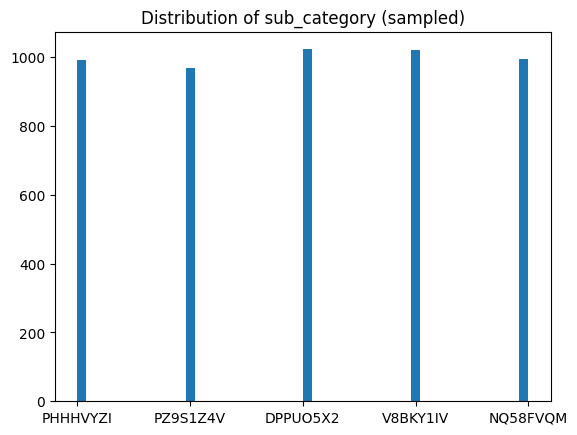

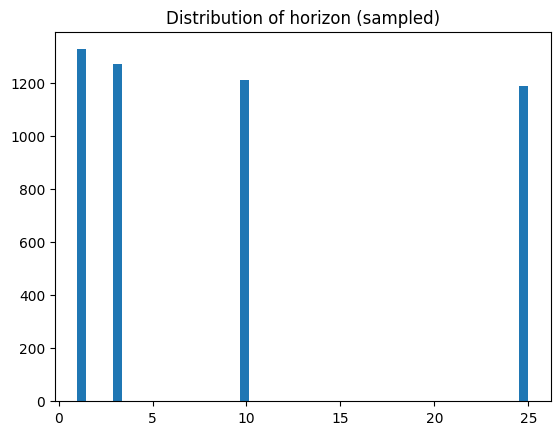

In [17]:
sample_df = train_df.select(num_cols[1:4]).sample(5000)

for col in num_cols[1:4]:
    values = sample_df[col].to_numpy()

    print(" ")
    plt.figure()
    plt.hist(values, bins=50)
    plt.title(f"Distribution of {col} (sampled)")
    plt.show()
    print(" ")

Volatility Check

In [18]:
# Rolling Volatility
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_std(window_size=10)
    .over("code")
    .alias("y_volatility")
])

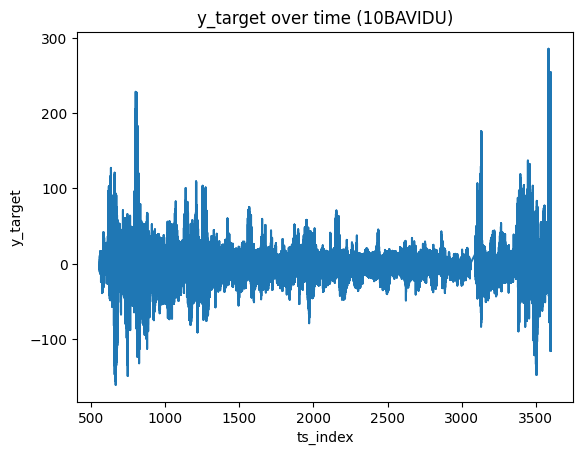

In [19]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [20]:
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_mean(window_size=10)
    .over("code")
    .alias("y_rolling_mean")
])
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""4KUR2ZOZ__II90M002__PZ9S1Z4V__…","""4KUR2ZOZ""","""II90M002""","""PZ9S1Z4V""",1.0,1014,43.0,13.115787,6.277544,14.624578,8.825246,7.221007,15.02276,0.017387,0.016836,0.001998,0.000355,3.380752,0.059289,-0.012163,0.0,0.007767,0.000704,0.000397,0.005514,0.022799,0.029132,1.755099,0.0,-0.354856,98.506666,153.188526,0.0,0.218606,0.085394,0.061135,0.000417,…,145.03507,46129.783936,182459.63692,4.0535e6,257089.655987,0.00004,4.9781e6,0.248025,157056.362704,14705.572108,0.145021,6.418604,0.346504,8.913995,6.003599,0.260186,2.166752,-0.347681,-0.279015,-3.315481,2.72507,3.21289,6.601512,-0.029306,-0.047036,-0.000607,-0.000964,-0.045142,-0.001518,-0.285578,3.395386,0.038344,0.0,0.043845,2414.850688,0.122962,0.030242
"""HYOGKLEV__916L3K5Q__PZ9S1Z4V__…","""HYOGKLEV""","""916L3K5Q""","""PZ9S1Z4V""",10.0,2666,14.0,15.400782,1.234017,10.298327,1.388271,11.845435,14.490426,0.000424,0.016557,0.000049,0.000186,0.657112,0.170508,0.130831,0.0,0.029013,0.035154,0.00217,0.059106,0.082848,0.738043,0.392513,-14.854218,15.331866,-12.060308,1.558231,0.0,0.00457,0.022638,0.041451,0.006878,…,806.707171,639.815288,15944.047526,6235.65553,17109.229411,0.17212,61724.140675,2.692235,2209.088988,141.688169,0.016913,0.35902,6.407596,0.154032,5.825895,0.403093,10.477436,-11.642927,-0.112161,-0.7681,0.081375,5.590048,11.459579,-0.001671,-0.033352,-0.000592,-0.000744,-0.002133,-0.002044,-0.010681,2.11992,0.132201,0.0,-0.071133,3148.504807,0.150424,0.109237
"""6LB028J8__HDODPOXE__PZ9S1Z4V__…","""6LB028J8""","""HDODPOXE""","""PZ9S1Z4V""",1.0,1071,27.0,11.365714,4.503935,7.3732,10.735732,8.470209,8.591085,0.002874,0.017437,0.007241,0.000276,0.258889,3.261347,-0.010587,0.007807,0.00283,0.004722,0.021819,0.093287,0.371985,0.036223,0.016229,18.69376,0.362406,-23.870896,-0.270401,1.141991,0.068222,0.021168,0.028558,0.021134,…,548.631398,123802.903353,314427.84698,4.5789e6,5.0468e6,0.007253,3.0780e6,26.042485,1374.929674,9661.641889,0.09005,2.310968,0.165293,4.256106,5.77956,6.643926,6.016545,-6.70779,-0.172712,-0.113656,0.133755,1.110079,10.760846,-0.000507,-0.001172,-0.033327,-0.0333,-0.041455,-0.001235,-0.01021,0.21549,2.910619,1.0,-0.012483,10566.519569,0.041689,-0.062213
"""1HEMHZK2__YP5Z0HWJ__PHHHVYZI__…","""1HEMHZK2""","""YP5Z0HWJ""","""PHHHVYZI""",25.0,2554,95.0,5.435265,2.447508,6.544696,8.51341,12.832802,1.047391,0.000498,0.006802,0.000449,0.01158,0.056127,2.027113,-0.085292,0.018736,0.000419,0.000913,0.001414,0.001732,0.002521,0.007344,0.053941,0.0,0.578361,44.806061,4.106781,0.025926,2.780681,2.057829,2.196915,0.016007,…,232.556394,6211.033341,73936.275702,123752.94758,3877.294706,0.005834,13757.032327,23.524781,4739.33287,65.53643,8.313406,0.119172,2.200791,0.099936,0.764075,1.026083,0.820451,-0.274232,-1.475602,-3.908353,3.388928,0.242412,0.217146,-0.000558,-0.000135,-0.000877,-0.000061,-0.001697,-0.000075,0.012733,1.649407,0.041523,2.0,-0.000292,734798.794818,0.00158,-0.002168
"""1HEMHZK2__6TA07NOO__DPPU

In [21]:
# Feature Importance Correlation
corr_df = train_df.select(
    [pl.corr(col, "y_target").alias(col) for col in num_cols[:10]]
)

print(corr_df)

shape: (1, 10)
┌─────┬──────────┬──────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id  ┆ sub_code ┆ sub_category ┆ horizon   ┆ … ┆ feature_c ┆ feature_d ┆ feature_e ┆ feature_f │
│ --- ┆ ---      ┆ ---          ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64 ┆ f64      ┆ f64          ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN ┆ NaN      ┆ NaN          ┆ -0.018719 ┆ … ┆ 0.00057   ┆ 0.000097  ┆ -0.000574 ┆ -0.000027 │
└─────┴──────────┴──────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [2]:
#Obtain the processed training dataset below to skip pre-processing runtime.
if not os.path.exists("train_processed.parquet"):
    print("Downloading dataset...")
    !gdown --id 1jlpQvegfMNeyUYfPrZB9asbaP9zejChI -O train_processed.parquet
assert os.path.exists("train_processed.parquet"), "Download failed!"

#Assigned processed trained dataset to variable. important!
print("Loading data...")
train_df = pl.scan_parquet("train_processed.parquet")
print("Processed training data obtained and assigned.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1jlpQvegfMNeyUYfPrZB9asbaP9zejChI
From (redirected): https://drive.google.com/uc?id=1jlpQvegfMNeyUYfPrZB9asbaP9zejChI&confirm=t&uuid=3cb9c064-bb8c-447d-9f54-7073eb1066ac
To: /content/train_processed.parquet
100% 643M/643M [00:04<00:00, 144MB/s]
Loading data...
Processed training data obtained and assigned.


# Baseline Model

First, the necessary libraries and modules are imported for the creation of this base model, which includes using HistGradientBoostingRegressor.

In [3]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

SEED = 42

train_df = train_df.collect()
print(train_df.shape)
train_df.head()

(5337414, 96)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",3.0,3531,141.0,3.475385,15.13462,3.265031,10.380979,8.83843,2.01938,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,0.670754,0.017167,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3531,134.0,12.707232,11.597299,6.034944,13.931955,9.418021,16.584339,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,5.601772,0.010329,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",25.0,3531,119.0,11.262484,1.45387,6.210146,8.292425,1.175443,15.234003,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,8.425576,0.016712,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3531,143.0,2.296699,1.939771,15.459024,8.540194,16.673829,14.100175,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,-2.795824,0.032189,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3532,142.0,4.631196,2.84

Next, we define the dataset with focus on features, weight and target.

In [4]:
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON = "horizon"
TS_INDEX = "ts_index"
TARGET = "y_target"
WEIGHT = "weight"
VOLATILITY = "y_volatility"
ROLLING_MEAN = "y_rolling_mean"

SAMPLE_FRAC = 0.1

train_df = (
    train_df
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

FEATURES = [c for c in train_df.columns if c not in [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX, TARGET, WEIGHT, VOLATILITY, ROLLING_MEAN]]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)
w = train_df.select(WEIGHT)

Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [5]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse(y_true, y_pred, w) -> float:

    denom = np.sum(w * y_true ** 2)
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))

def compute_weights(df):

    return np.ones(len(df))

Time-series validation splits are then defined to prevent data leakage.

---



In [6]:
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

splits = list(tscv.split(X))

print(f"Number of splits: {len(splits)}")

Number of splits: 5


Most importantly, we train the baseline model. We are using the tree based model, HistGradientBoostingRegressor.

In [7]:
def train_baseline_hgbr(X, y, w, splits):

    X_np = np.asarray(X)
    y_np = np.asarray(y).flatten()
    w_np = np.asarray(w).flatten()

    oof_predictions = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]

        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        #scaling
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        #model
        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.11,
            max_depth=6,
            min_samples_leaf=20,
            l2_regularization=0.5,
            max_bins=255,
            validation_fraction=0.5,
            n_iter_no_change=60,
            random_state=SEED
        )

        model.fit(X_train, y_train_scaled, sample_weight=w_train)

        preds_scaled = model.predict(X_val)
        preds = preds_scaled * y_std + y_mean

        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_predictions[val_idx] = preds

    return oof_predictions

Now we display the score and dataset stats produced by the trained model

In [8]:
oof_preds = train_baseline_hgbr(X, y, w, splits)
train_weights = compute_weights(train_df)

oof_score = weighted_rmse(
    train_df[TARGET].to_numpy(),
    oof_preds,
    train_weights
)

print(f"OOF Score: {oof_score:.5f}")
print("----------------------------")
y_true = train_df[TARGET].to_numpy()

print("OOF mean:", oof_preds.mean())
print("y_true mean:", y_true.mean())
print("OOF min/max:", oof_preds.min(), oof_preds.max())
print("y_true min/max:", y_true.min(), y_true.max())
print("X shape:", X.shape)
print("Number of splits:", len(splits))

OOF Score: 0.09147
----------------------------
OOF mean: -0.5366845753029574
y_true mean: -0.6660210131631762
OOF min/max: -86.10088142965665 20.338573067022253
y_true min/max: -1351.8651089498348 2125.2380157082684
X shape: (533741, 86)
Number of splits: 5


Adding compute functions - feature experiment validation support.

In [9]:
def compute_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def compute_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_absolute_error(y_true, y_pred)

Use rmse and mae to compute fold metrics - feature experiment validation support.

In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_fold_metrics(y_true, y_pred, splits):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fold_scores = []

    for fold, (_, val_idx) in enumerate(splits):
        y_val = y_true[val_idx]
        y_pred_val = y_pred[val_idx]

        # Calculate MSE and then take the square root for RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)

        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})

    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae = np.mean([f["mae"] for f in fold_scores])

    return fold_scores, mean_rmse, mean_mae

Display the folds using rmse and mae - feature experiment validation support.

In [11]:
oof_preds = train_baseline_hgbr(X, y, w, splits)

fold_scores, mean_rmse, mean_mae = compute_fold_metrics(y, oof_preds, splits)

print("Fold-wise scores:")
for f in fold_scores:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")

print(f"\nMean RMSE: {mean_rmse:.4f}, Mean MAE: {mean_mae:.4f}")

Fold-wise scores:
Fold 1 - RMSE: 22.7354, MAE: 4.0637
Fold 2 - RMSE: 32.6094, MAE: 5.3125
Fold 3 - RMSE: 37.9873, MAE: 7.1747
Fold 4 - RMSE: 27.8710, MAE: 5.8335
Fold 5 - RMSE: 28.6255, MAE: 6.6272

Mean RMSE: 29.9657, Mean MAE: 5.8023


Next, we evaluate the model using competition metric.
We shall perform the same operations on test_df as done on train_df. The first step is to preprocess the test data.

In [12]:
test_df_processed = (
    pl.scan_parquet("test.parquet")
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
    .collect(streaming=True)
)

exclude_cols_for_num_processing = [ID, CODE, SUBCODE, SUBCATEGORY, TS_INDEX, TARGET]

test_feature_cols = [
    col for col in test_df_processed.columns
    if col not in exclude_cols_for_num_processing and test_df_processed[col].dtype.is_numeric()
]

#Forward fill
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(CODE)
    .alias(col)
    for col in test_feature_cols
])

#Median imputation
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over(CODE))
    .alias(col)
    for col in test_feature_cols
])

#Rolling Volatility
if TARGET in test_df_processed.columns:
  test_df_processed = test_df_processed.with_columns([
      pl.col(TARGET)
      .rolling_std(window_size=10)
      .over(CODE)
      .alias("y_volatility")
  ])

#Rolling Mean
if TARGET in test_df_processed.columns:
  test_df_processed = test_df_processed.with_columns([
      pl.col(TARGET)
      .rolling_mean(window_size=10)
      .over(CODE)
      .alias("y_rolling_mean")
  ])

print("Processed Test DataFrame Head:")
display(test_df_processed.head())

print("\nProcessed Test DataFrame Schema:")
print(test_df_processed.schema)

Processed Test DataFrame Head:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",25.0,4175,185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",1.0,4175,210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",10.0,4175,201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3.0,4175,208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3.0,4176,207.0,14.844531,1.652745,3.959252,4


Processed Test DataFrame Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Float64, 'ts_index': Int32, 'feature_a': Float64, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float6

Secondly, we must select our features for testing and preview the test.

In [13]:
X_test = test_df_processed.select(FEATURES)

print("\nX_test Head:")
display(X_test.head())


X_test Head:


feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
207.0,14.844531,1.652745,3.959252,4.966838,3.946401,10.636208,0.001842,0.000218,0.000067,0.000089,3.230579,0.646894,2.057089,4.393155,0.691346,11.689794,0.682537,1.410798,47.797074,3.534047,0.939,2.729261,16.588922,59.151639,337.547998,0.024871

Finally, we must train the sample data for testing to obtain predictions and construct a submission

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor

print("Training final model on sampled training data...")
final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    random_state=SEED
)

final_model.fit(X.to_numpy(), y.to_numpy().flatten())

print("\nMaking predictions on test data...")

test_preds = final_model.predict(X_test.to_numpy())

submission = test_df_processed.select(["id"]).with_columns(
    pl.Series("prediction", test_preds)
)

print(submission)

Training final model on sampled training data...

Making predictions on test data...
shape: (1_447_107, 2)
┌─────────────────────────────────┬────────────┐
│ id                              ┆ prediction │
│ ---                             ┆ ---        │
│ str                             ┆ f64        │
╞═════════════════════════════════╪════════════╡
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.850228   │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.55957    │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.55957    │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.850228   │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.330158   │
│ …                               ┆ …          │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
└─────────────────────────────────┴────────────┘


To conclude with model building, we display the key results in a table.

In [15]:
import pandas as pd
import numpy as np

fold_scores, mean_rmse, mean_mae = compute_fold_metrics(y, oof_preds, splits)

oof_score = weighted_rmse(
    train_df[TARGET].to_numpy(),
    oof_preds,
    train_weights
)

results_table = pd.DataFrame({
    "model": ["HistGradientBoosting_Baseline"],
    "mean_cv_score": [np.mean([fs["rmse"] for fs in fold_scores])],
    "std_cv_score": [np.std([fs["rmse"] for fs in fold_scores])],
    "final_test_score": [oof_score]
})

print(results_table.to_string(index=False))

                        model  mean_cv_score  std_cv_score  final_test_score
HistGradientBoosting_Baseline      29.965706      5.095024          0.091472


# Feature Engineering

### Feature Selection

In [20]:
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# =====================================
# Validation Splits
# =====================================
def time_splits(n):
    fold_size = n // (N_SPLITS + 1)

    splits = []
    for i in range(1, N_SPLITS + 1):
        train_end = i * fold_size
        val_end = (i + 1) * fold_size

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)

        splits.append((train_idx, val_idx))
    return splits

In [21]:
# =====================================
# Computing Temporal Feature Importance
# =====================================
def compute_temporal_importance(df, target, n_repeats=5):
    feature_df = df.select(
        pl.col("^feature.*$"),
        target
    )

    X = feature_df.drop(target)
    y = feature_df.select(target).to_numpy().ravel()

    X_np = X.to_numpy()
    feature_names = X.columns

    splits = time_splits(len(X_np))

    all_importances = []

    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"Processing fold {fold+1}")

        X_train = X_np[train_idx]
        y_train = y[train_idx]

        X_val = X_np[val_idx]
        y_val = y[val_idx]

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        perm = permutation_importance(
            model,
            X_val,
            y_val,
            n_repeats=n_repeats,
            random_state=SEED,
            n_jobs=-1
        )

        all_importances.append(perm.importances_mean)

    importances_array = np.array(all_importances)

    mean_importance = importances_array.mean(axis=0)
    std_importance = importances_array.std(axis=0)

    stability_score = mean_importance / (std_importance + 1e-6)

    feature_importance_df = pl.DataFrame({
        "feature": feature_names,
        "mean_importance": mean_importance,
        "std_importance": std_importance,
        "stability_score": stability_score
    }).sort("mean_importance", descending=True)

    return feature_importance_df

# =====================================
# Selecting Features (based on stability + importance)
# =====================================
def select_features(
    feature_importance_df,
    unstable_threshold,
    stability_floor=0.5
):
    # Stable
    stable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > 0) &
            (pl.col("stability_score") > 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    # Unstable but useful
    unstable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > unstable_threshold) &
            (pl.col("stability_score") > stability_floor) &
            (pl.col("stability_score") <= 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    final_features = list(dict.fromkeys(
        stable_features + unstable_features
    ))

    print(f"Stable: {len(stable_features)}")
    print(f"Unstable added: {len(unstable_features)}")
    print(f"Final total: {len(final_features)}")
    print(f"Final Features: {final_features}")

    return final_features

In [56]:
# compute importance
importance_df = compute_temporal_importance(train_df, TARGET)

# inspect and select thresholds
print(importance_df.select("mean_importance").describe())

threshold = 0.01

# select features
final_features = select_features(
    importance_df,
    unstable_threshold=threshold
)

Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.009872        │
│ std        ┆ 0.025877        │
│ min        ┆ -0.017272       │
│ 25%        ┆ -0.000077       │
│ 50%        ┆ 0.001876        │
│ 75%        ┆ 0.005777        │
│ max        ┆ 0.142759        │
└────────────┴─────────────────┘
Stable: 14
Unstable added: 8
Final total: 22
Final Features: ['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


In [28]:
#Save important feature list to json and final feature dataset to parquet
'''
import json

final_df = train_df.select(final_features)

final_df.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/final_features.parquet"
)

with open("/content/drive/MyDrive/COMP3608-PROJECT/final_features.json", "w") as f:
    json.dump(final_features, f)
'''

'\nimport json\n\nfinal_df = train_df.select(final_features)\n\nfinal_df.write_parquet(\n    "/content/drive/MyDrive/COMP3608-PROJECT/final_features.parquet"\n)\n\nwith open("/content/drive/MyDrive/COMP3608-PROJECT/final_features.json", "w") as f:\n    json.dump(final_features, f)\n'

In [29]:
#Loads final features from Google Drive instantaneously
import json

if not os.path.exists("final_features.json"):
    print("Downloading final features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O final_features.json
assert os.path.exists("final_features.json"), "Download failed!"


with open("/content/final_features.json", "r") as f:
    final_features = json.load(f)

print(final_features)

['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


In [41]:
#Obtain the final feature columns
#Optional - to be used
if not os.path.exists("final_features.parquet"):
    print("Downloading dataset...")
    !gdown --id 1mDjBRCZiR-yCA8KnzQPkdBn-lcLWTOUV -O final_features.parquet
assert os.path.exists("final_features.parquet"), "Download failed!"

#Assigned final feature columns to variable. important!
print("Loading data...")
final_df = pl.scan_parquet("final_features.parquet")
print("Processed final feature dataset.")
print(final_df.head())

Loading data...
Processed final feature dataset.
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SLICE[offset: 0, len: 5]
  Parquet SCAN [final_features.parquet]
  PROJECT */22 COLUMNS
  ESTIMATED ROWS: 533741


In [30]:
horizon_feature_sets = {}

for h in [1, 3, 10, 25]:
  print(f"\n==== Horizon {h} ====")

  df_h = train_df.filter(pl.col("horizon") == h)

  # compute importance
  importance_df = compute_temporal_importance(df_h, TARGET)

  # inspect and select thresholds
  print(importance_df.select("mean_importance").describe())

  threshold = 0.01

  # select features
  final_features = select_features(
      importance_df,
      unstable_threshold=threshold
  )

  horizon_feature_sets[h] = final_features


==== Horizon 1 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.001793        │
│ std        ┆ 0.007565        │
│ min        ┆ -0.003083       │
│ 25%        ┆ -0.000249       │
│ 50%        ┆ 0.000145        │
│ 75%        ┆ 0.001057        │
│ max        ┆ 0.066025        │
└────────────┴─────────────────┘
Stable: 6
Unstable added: 1
Final total: 7
Final Features: ['feature_o', 'feature_af', 'feature_bz', 'feature_s', 'feature_aj', 'feature_cd', 'feature_as']

==== Horizon 3 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │


In [37]:
#Saves horizon feature sets to json in drive
'''
import json

with open("/content/drive/MyDrive/COMP3608-PROJECT/horizon_feature_sets.json", "w") as f:
    json.dump(horizon_feature_sets, f)
'''

'\nimport json\n\nwith open("/content/drive/MyDrive/COMP3608-PROJECT/horizon_feature_sets.json", "w") as f:\n    json.dump(horizon_feature_sets, f)\n'

In [39]:
#Outputs and downloads horizon feature sets instantaneously from drive
import json

if not os.path.exists("horizon_feature_sets.json"):
    print("Downloading horizon features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O horizon_feature_sets.json
assert os.path.exists("horizon_feature_sets.json"), "Download failed!"

with open("/content/horizon_feature_sets.json", "r") as f:
    horizon_feature_sets = json.load(f)

horizon_feature_sets = {
    int(k): v for k, v in horizon_feature_sets.items()
}

print(horizon_feature_sets)

{1: ['feature_o', 'feature_af', 'feature_bz', 'feature_s', 'feature_aj', 'feature_cd', 'feature_as'], 3: ['feature_by', 'feature_am', 'feature_af', 'feature_s', 'feature_y', 'feature_ag', 'feature_bk', 'feature_bd', 'feature_o'], 10: ['feature_bo', 'feature_z', 'feature_x', 'feature_q', 'feature_b', 'feature_u', 'feature_bz', 'feature_m', 'feature_ab', 'feature_bn', 'feature_o', 'feature_bs'], 25: ['feature_u', 'feature_bp', 'feature_bs', 'feature_bh', 'feature_v', 'feature_bz', 'feature_m', 'feature_al', 'feature_z', 'feature_af', 'feature_be', 'feature_o', 'feature_bg', 'feature_bl']}


### Lag Features

In [ ]:
# Generate lag features
def generate_lags(df, feature_cols, lag_list, group_col=CODE):
    lag_exprs = []
    for col in feature_cols:
        for lag in lag_list:
            lag_exprs.append(
                pl.col(col)
                .shift(lag)
                .over(group_col)
                .alias(f"feature_lag_{lag}_{col}")
            )
    return df.with_columns(lag_exprs)


# Lag sets to evaluate
lag_sets = [
    [1],
    [1, 2],
    [1, 2, 3],
    [1, 2, 3, 5],
    [1, 2, 3, 5, 10],
    [1, 2, 3, 5, 10, 25]
]

results = []

for lags in lag_sets:
    print(f"\n==== Testing lags: {lags} ====")

    # Generate lag features
    df_lagged = generate_lags(train_df.clone(), [TARGET], lags, [CODE, SUBCODE, SUBCATEGORY])

    # Compute temporal importance
    importance_df = compute_temporal_importance(df_lagged, TARGET)

    # Extract lag feature stats
    lag_features = [f"feature_lag_{lag}_{TARGET}" for lag in lags]

    lag_importance = (
        importance_df
        .filter(pl.col("feature").is_in(lag_features))
        .sort("mean_importance", descending=True)
    )

    # Summary stats
    num_selected = (
        lag_importance
        .filter(pl.col("mean_importance") > 0)
        .height
    )

    avg_importance = lag_importance["mean_importance"].mean()
    avg_stability = lag_importance["stability_score"].mean()

    print(f"Lag features with signal (>0): {num_selected}")
    print(f"Average lag importance: {avg_importance:.6f}")
    print(f"Average lag stability: {avg_stability:.4f}")

    print("\nTop lag features:")
    print(lag_importance.head(10))

    if lag_importance.height > 0:
      best_lag = lag_importance.row(0)
      print(f"Best lag: {best_lag[0]} | importance: {best_lag[1]:.6f}")

    # Store results
    results.append({
        "lags": lags,
        "num_lag_features_with_signal": num_selected,
        "avg_lag_importance": avg_importance,
        "avg_lag_stability": avg_stability,
        "top_lag_features": lag_importance.head(5)
    })


==== Testing lags: [1] ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Lag features with signal (>0): 1
Average lag importance: 0.200819
Average lag stability: 6.8672

Top lag features:
shape: (1, 4)
┌────────────────────────┬─────────────────┬────────────────┬─────────────────┐
│ feature                ┆ mean_importance ┆ std_importance ┆ stability_score │
│ ---                    ┆ ---             ┆ ---            ┆ ---             │
│ str                    ┆ f64             ┆ f64            ┆ f64             │
╞════════════════════════╪═════════════════╪════════════════╪═════════════════╡
│ feature_lag_1_y_target ┆ 0.200819        ┆ 0.029242       ┆ 6.86716         │
└────────────────────────┴─────────────────┴────────────────┴─────────────────┘
Best lag: feature_lag_1_y_target | importance: 0.200819

==== Testing lags: [1, 2] ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Lag features w

### Rolling Window Features

In [ ]:
def generate_rolling(df, feature_cols, windows, group_col=CODE):
    exprs = []

    for col in feature_cols:
        for w in windows:
            shifted = pl.col(col).shift(1)

            exprs.extend([
                shifted.rolling_mean(w).over(group_col)
                .alias(f"feature_roll_mean_{w}_{col}"),

                shifted.rolling_std(w).over(group_col)
                .alias(f"feature_roll_std_{w}_{col}"),

                shifted.rolling_skew(w).over(group_col)
                .alias(f"feature_roll_skew_{w}_{col}"),

                shifted.rolling_kurtosis(w).over(group_col)
                .alias(f"feature_roll_kurt_{w}_{col}")
            ])

    return df.with_columns(exprs)


# Rolling Windows
window_sets = [
    [3],
    [3, 5],
    [3, 5, 10],
    [3, 5, 10, 25]
]

results = []

for windows in window_sets:
    print(f"\n==== Testing windows: {windows} ====")

    df_roll = generate_rolling(train_df.clone(), [TARGET], windows, [CODE, SUBCODE, SUBCATEGORY])

    # Compute importance
    importance_df = compute_temporal_importance(df_roll, TARGET)

    # Extract rolling features
    roll_features = [
        f"feature_roll_{stat}_{w}_{TARGET}"
        for w in windows
        for stat in ["mean", "std", "skew", "kurt"]
    ]

    roll_importance = (
        importance_df
        .filter(pl.col("feature").is_in(roll_features))
        .sort("mean_importance", descending=True)
    )

    # Stats
    num_signal = roll_importance.filter(pl.col("mean_importance") > 0).height

    avg_importance = roll_importance["mean_importance"].mean()
    avg_stability = roll_importance["stability_score"].mean()

    print(f"Rolling features with signal: {num_signal}")
    print(f"Avg importance: {avg_importance}")
    print(f"Avg stability: {avg_stability}")

    print("\nTop rolling features:")
    print(roll_importance.head(10))

    results.append({
        "windows": windows,
        "num_signal": num_signal,
        "avg_importance": avg_importance,
        "avg_stability": avg_stability,
        "top_features": roll_importance.head(5)
    })


==== Testing windows: [3] ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Rolling features with signal: 4
Avg importance: 0.08938580618456426
Avg stability: 10.476595198482688

Top rolling features:
shape: (4, 4)
┌──────────────────────────────┬─────────────────┬────────────────┬─────────────────┐
│ feature                      ┆ mean_importance ┆ std_importance ┆ stability_score │
│ ---                          ┆ ---             ┆ ---            ┆ ---             │
│ str                          ┆ f64             ┆ f64            ┆ f64             │
╞══════════════════════════════╪═════════════════╪════════════════╪═════════════════╡
│ feature_roll_mean_3_y_target ┆ 0.293828        ┆ 0.007552       ┆ 38.902149       │
│ feature_roll_std_3_y_target  ┆ 0.061806        ┆ 0.044546       ┆ 1.387437        │
│ feature_roll_skew_3_y_target ┆ 0.001326        ┆ 0.001071       ┆ 1.236778        │
│ feature_roll_kurt_3_y_target ┆ 0.000583        ┆ 

### Horizon Based Features

Library imports and variable initialization.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.base import clone

X_base = X.clone()
X_base = X_base.with_columns(train_df["horizon"].alias("horizon"))

y_base = "y_target"
y_base = train_df.select(y_base)

Creating horizon features using grouping and interactions.

In [ ]:
def create_horizon_features(X):
    X_new = X.clone()

    #grouping
    X_new = X_new.with_columns(
        pl.when(pl.col("horizon") == 1).then(0)
        .when(pl.col("horizon") == 3).then(1)
        .when(pl.col("horizon") == 10).then(2)
        .otherwise(3)
        .alias("horizon_group")
    )

    #selected interactions
    important_cols = [
        "feature_v",
        "feature_bz",
        "feature_al",
        "feature_bp",
        "feature_bm"
    ]

    for col in important_cols:
        if col in X_new.columns:
            X_new = X_new.with_columns(
                (pl.col(col) * pl.col("horizon"))
                .alias(f"{col}_x_horizon")
            )

    return X_new

Create the features and display the change in shape.

In [ ]:
X_horizon = create_horizon_features(X_base)

print("Original shape:", X_base.shape)
print("New shape:", X_horizon.shape)

Original shape: (533741, 87)
New shape: (533741, 93)


Train the horizon model.

In [ ]:
def train_model(X, y, w, splits, model):

    X_np = X.to_numpy()
    y_np = y.to_numpy().flatten()
    w_np = w.to_numpy().flatten()

    oof_preds = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        #Target scaling logic
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        m = clone(model)
        #Apply weights during training
        m.fit(X_train, y_train_scaled, sample_weight=w_train)

        #Inverse transform predictions and clip
        preds_scaled = m.predict(X_val)
        preds = preds_scaled * y_std + y_mean
        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_preds[val_idx] = preds

    return oof_preds

Compare the Baseline RMSE and Horizon RMSE to identify improvements.

In [ ]:
import numpy as np

oof_horizon_score = train_model(
    X_horizon,
    y_base,
    w,
    splits,
    final_model,
)

valid_indices = np.concatenate([
    val_idx for _, val_idx in splits
])

valid_mask = np.zeros(len(oof_horizon_score), dtype=bool)
valid_mask[valid_indices] = True

horizon_weighted_score = weighted_rmse(
    train_df[TARGET].to_numpy()[valid_mask],
    oof_horizon_score[valid_mask],
    train_weights[valid_mask]
)

baseline_weighted_score = weighted_rmse(
    train_df[TARGET].to_numpy()[valid_mask],
    oof_preds[valid_mask],
    train_weights[valid_mask]
)

print(f"Baseline Weighted RMSE: {baseline_weighted_score:.5f}")
print(f"Horizon Weighted RMSE:  {horizon_weighted_score:.5f}")
print(f"Improvement: {baseline_weighted_score - horizon_weighted_score:.5f}")

Baseline Weighted RMSE: 0.10587
Horizon Weighted RMSE:  0.05624
Improvement: 0.04962


The following bar chart illustrates the results above.

              Model  Weighted RMSE
0          Baseline       0.105865
1  Horizon Features       0.056241


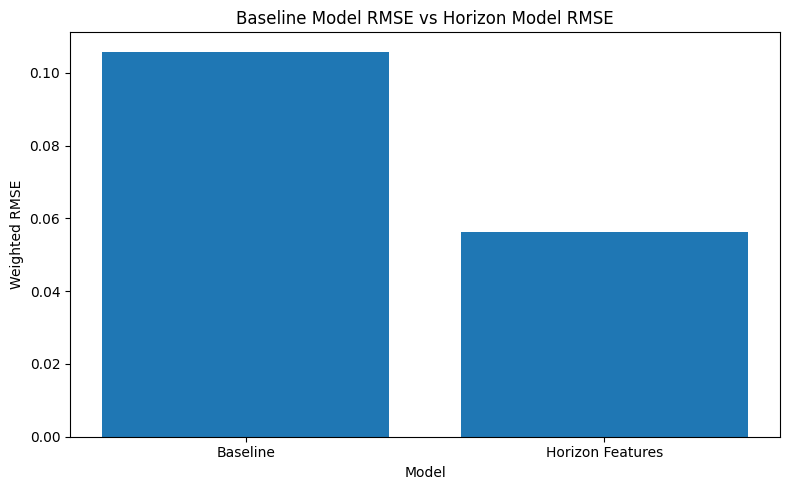

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#Final RMSE values
baseline_rmse = baseline_weighted_score
horizon_rmse = horizon_weighted_score

#Create comparison dataframe
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Horizon Features"],
    "Weighted RMSE": [baseline_rmse, horizon_rmse]
})

print(comparison_df)

#Bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Weighted RMSE"]
)

plt.title("Baseline Model RMSE vs Horizon Model RMSE")
plt.xlabel("Model")
plt.ylabel("Weighted RMSE")
plt.tight_layout()
plt.show()

The horizon model has less root mean square error than the baseline model.

## Feature Interaction

In [32]:
#imports
import numpy as np
import polars as pl
import itertools
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.base import clone
from sklearn.inspection import permutation_importance

#allows more feature interactions
final_model = HistGradientBoostingRegressor(
    max_iter=300,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=50,
)

#variable conversion
X_np_base = X.to_numpy()
y_np = y.to_numpy().flatten()
w_np = w.to_numpy().flatten()
w_np = w_np / (w_np.sum() + 1e-12)

#evaluating feature permutation importance
importances = np.zeros(X_np_base.shape[1])
for train_idx, val_idx in splits[:3]:
    model_tmp = clone(final_model)
    model_tmp.fit(X_np_base[train_idx], y_np[train_idx], sample_weight=w_np[train_idx])

    perm = permutation_importance(
        model_tmp,
        X_np_base[val_idx],
        y_np[val_idx],
        n_repeats=3,
        random_state=42,
        scoring="neg_root_mean_squared_error"
    )

    importances += perm.importances_mean

importances /= 3
top_idx = np.argsort(importances)[-5:]

#feature engineering
def clean_interactions(X, idxs):
    cols = [X]

    for i in range(len(idxs)):
        for j in range(i+1, len(idxs)):
            a, b = idxs[i], idxs[j]

            f1 = X[:, a]
            f2 = X[:, b]

            mult = f1 * f2
            diff = f1 - f2
            summ = f1 + f2

            cols.append(mult[:, None])
            cols.append(diff[:, None])
            cols.append(summ[:, None])

    return np.hstack(cols)

#oof interaction model training
def run_oof_interactions(X_np, y_np, w_np, splits, model):
    oof_preds = np.zeros(len(X_np))

    for train_idx, val_idx in splits:
        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]

        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0

        y_train_scaled = (y_train - y_mean) / y_std

        m = clone(model)
        m.fit(X_train, y_train_scaled, sample_weight=w_train)

        preds_scaled = m.predict(X_val)
        preds = preds_scaled * y_std + y_mean

        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_preds[val_idx] = preds

    return oof_preds

#baseline output
print("Baseline Model - Fold-wise scores:")
for f in fold_scores:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")

print(f"Mean RMSE: {mean_rmse:.4f}, Mean MAE: {mean_mae:.4f}")
print(" ")

#run feature interactions - one at a time for best
best_rmse = float("inf")
best_k = None
best_preds = None
for k in [2, 3]:
    idxs = top_idx[:k]

    X_interact = clean_interactions(X_np_base, idxs)
    X_np = X_interact

    #memory cleanup
    del X_interact
    import gc
    gc.collect()

    oof_preds_interact = run_oof_interactions(
        X_np,
        y_np,
        w_np,
        splits,
        final_model,
    )

    #get rmse and mae
    FI_fold_scores, FI_mean_rmse, FI_mean_mae = compute_fold_metrics(y, oof_preds_interact, splits)

    #output per feature interaction
    print("Feature Interaction Model - Fold-wise scores:")
    print(f"K = {k}")
    for f in FI_fold_scores:
        print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
    print(f"Mean RMSE: {FI_mean_rmse:.4f}, Mean MAE: {FI_mean_mae:.4f}")
    print("Pred std:", np.std(oof_preds_interact))
    print("   ")

    #find best prediction
    if FI_mean_rmse < best_rmse:
        best_rmse = FI_mean_rmse
        best_k = k
        best_preds = oof_preds_interact.copy()

#compute weighted rmse for both models
train_weights_np = train_weights / (train_weights.sum() + 1e-12)
weights = w_np / (w_np.sum() + 1e-12)

interaction_weighted_score = weighted_rmse(
    y_np,
    best_preds,
    weights
)

baseline_weighted_score = weighted_rmse(
    y_np,
    oof_preds,
    weights
)

#additional output
print("----------------------------------------------------------")
print("Best k:", best_k)
print("Pred std (interaction):", np.std(best_preds))
print("Pred std (baseline):", np.std(oof_preds))
print("Top feature indices:", top_idx)
print("Importances:", importances[top_idx])

print(f"\nBaseline Weighted RMSE: {baseline_weighted_score:.5f}")
print(f"Feature Interaction Weighted RMSE: {interaction_weighted_score:.5f}")
print(f"Improvement: {baseline_weighted_score - interaction_weighted_score:.5f}")

Baseline Model - Fold-wise scores:
Fold 1 - RMSE: 22.7354, MAE: 4.0637
Fold 2 - RMSE: 32.6094, MAE: 5.3125
Fold 3 - RMSE: 37.9873, MAE: 7.1747
Fold 4 - RMSE: 27.8710, MAE: 5.8335
Fold 5 - RMSE: 28.6255, MAE: 6.6272
Mean RMSE: 29.9657, Mean MAE: 5.8023
 
Feature Interaction Model - Fold-wise scores:
K = 2
Fold 1 - RMSE: 23.2112, MAE: 4.1042
Fold 2 - RMSE: 33.6037, MAE: 5.4452
Fold 3 - RMSE: 37.3936, MAE: 7.0323
Fold 4 - RMSE: 27.8533, MAE: 5.8009
Fold 5 - RMSE: 28.8064, MAE: 6.6725
Mean RMSE: 30.1737, Mean MAE: 5.8110
Pred std: 0.00011085823258220762
   
Feature Interaction Model - Fold-wise scores:
K = 3
Fold 1 - RMSE: 23.2112, MAE: 4.1042
Fold 2 - RMSE: 33.6037, MAE: 5.4452
Fold 3 - RMSE: 37.3936, MAE: 7.0323
Fold 4 - RMSE: 27.8533, MAE: 5.8009
Fold 5 - RMSE: 28.8064, MAE: 6.6725
Mean RMSE: 30.1737, Mean MAE: 5.8110
Pred std: 0.00011618639379317358
   
----------------------------------------------------------
Best k: 3
Pred std (interaction): 0.00011618639379317358
Pred std (baseline

The negative improvement from both fold metrics and weighted rmse conclude that feature interaction may not improve model performance, but rather add noise from redundancy as the current base model inherently handles feature interactions.

## Trend/Difference Feature

In [ ]:
#Create Difference Features
def generate_diff_features(df, feature_cols, group_col="code"):
    diff_exprs = []

    for col in feature_cols:
        diff_exprs.append(
            (pl.col(col) - pl.col(col).shift(1).over(group_col))
            .fill_null(0)
            .alias(f"{col}_diff_1")
        )

    return df.with_columns(diff_exprs)
#Apply to Dataset
# Generate difference features
df_diff = generate_diff_features(train_df, FEATURES)

# Collect new feature names
diff_cols = [f"{col}_diff_1" for col in FEATURES]

# Combine original + diff features
diff_features = FEATURES + diff_cols

# Prepare data
X_diff = df_diff.select(diff_features)
y_diff = df_diff.select(TARGET)
w_diff = df_diff.select(WEIGHT)

#Time Series Split
splits_diff = list(TimeSeriesSplit(n_splits=N_SPLITS).split(X_diff))
oof_preds_diff = train_baseline_hgbr(X_diff, y_diff, w_diff, splits_diff)

# Evaluate Performance
# Compute metrics
fold_scores_diff, mean_rmse_diff, mean_mae_diff = compute_fold_metrics(
    y_diff.to_numpy().flatten(),
    oof_preds_diff,
    splits_diff
)

# Weighted metric
diff_score = weighted_rmse(
    y_diff.to_numpy().flatten(),
    oof_preds_diff,
    w_diff.to_numpy().flatten()
)

print("\n=== Difference Feature Results ===")

for f in fold_scores_diff:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")

print(f"\nMean RMSE: {mean_rmse_diff:.4f}")
print(f"Mean MAE: {mean_mae_diff:.4f}")
print(f"Weighted Score: {diff_score:.5f}")


=== Difference Feature Results ===
Fold 1 - RMSE: 22.7170, MAE: 4.0677
Fold 2 - RMSE: 32.7766, MAE: 5.3216
Fold 3 - RMSE: 38.0645, MAE: 7.1623
Fold 4 - RMSE: 27.9503, MAE: 5.8357
Fold 5 - RMSE: 28.6054, MAE: 6.6262

Mean RMSE: 30.0228
Mean MAE: 5.8027
Weighted Score: 0.00000


In [ ]:
print("\n=== Comparison vs Baseline ===")
print(f"Baseline RMSE: {mean_rmse:.4f} | Diff RMSE: {mean_rmse_diff:.4f}")
print(f"Baseline MAE:  {mean_mae:.4f} | Diff MAE:  {mean_mae_diff:.4f}")



=== Comparison vs Baseline ===
Baseline RMSE: 29.9657 | Diff RMSE: 30.0228
Baseline MAE:  5.8023 | Diff MAE:  5.8027


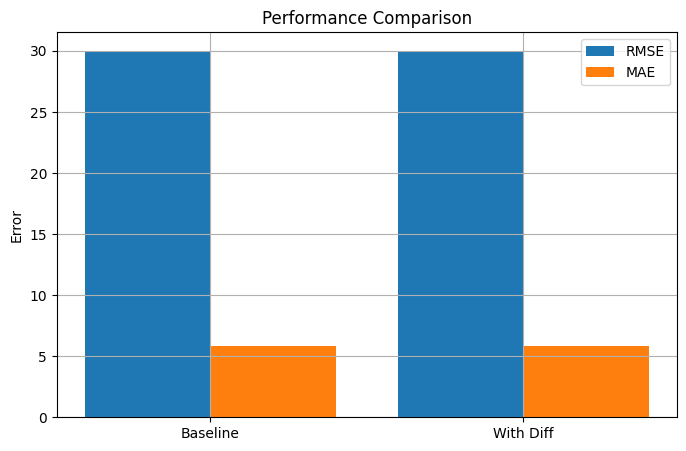

In [ ]:
labels = ["Baseline", "With Diff"]

rmse_vals = [mean_rmse, mean_rmse_diff]
mae_vals = [mean_mae, mean_mae_diff]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, rmse_vals, width=0.4, label="RMSE")
plt.bar(x + 0.2, mae_vals, width=0.4, label="MAE")

plt.xticks(x, labels)
plt.title("Performance Comparison")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation of Trend/Difference feature
The introduction of lag-1 difference features (x_t - x_{t-1}) was intended to capture short-term temporal changes within each code group, allowing the model to detect sudden deviations or behavioral shifts that may not be visible in the raw feature values alone. However, the experimental results show that including these features did not produce any measurable improvement in performance. Both RMSE and MAE remained essentially unchanged compared to the baseline model, indicating that the additional features did not contribute meaningful predictive signal.

This suggests that the original feature set already contains sufficient information for the model, or that the model itself is capable of implicitly learning temporal relationships without explicitly engineered difference features. It is also possible that the dataset does not exhibit strong short-term variation, or that differencing introduced noise that offset any potential benefit. As a result, the lag-1 difference features do not justify inclusion in the final model, reinforcing the importance of empirically validating feature engineering choices rather than assuming their effectiveness.